Questions:
1. Is the faceball (not smiling face) enough for the demo ? yes. (yes - we just need another line to make it smile <--> frown.
2. What is it that we want to replace in the faceball ? (suggestion - make it a  smiley face instead of a faceball - approved).
3. *Are we happy with the way I locate the data in the fastq file ?*
Option 1: (Demonstrates that the chemistry works) open the dna text library file (the fasta file) and go over it line by line. For each line, try to find it in the sequencing file (fastq).

Option 2: (Demonstrates the fidelity of the DNA storage method) process the fastq file line by line, determine whether it is data or noise, determine which data sequence it is (requires sequence number) and reconstruct the data blindly (i.e.: without knowledge of the original content).

Option 2 requires:
a. Adding a sequence number to each fragment.
b. Adding error correction.
c. Filtering the noise DNA (nanostructure DNA fragments, random DNA, what else ?)
d. Reconstructing the sequences from fragments.
e. Compensate for errors and remove ECC overhead.
f. Translate back to textual.
g. Add redundant information like "<" and "/>"
h. Reconstruct image from textual.

4. What do we need as an input for Alex's code ? we think that the fasta file is it - yes
5. Can we (should we ?) split the sequences into shorter sequences of less than 90 bases long ? - yes.

Omer's action items:
1. Split the sequences into 70 - 100 bases long fragments.
2. Overlap should be no more than 7 bases
3. Show using some graph that the data exists in the fastq file
4. Demonstrate the reverse mapping.

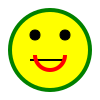

In [3]:
#@title { vertical-output: true}
from IPython.display import SVG, display
try:
  __import__('Bio')
except:
  !pip install --quiet biopython
try :
  __import__('reedsolo')
except:
  !pip install --quiet reedsolo

from Bio.Seq import Seq as seq
import numpy as np
import matplotlib.pyplot as plt

# An SVG is made out of a header, a footer, and in between them some lines that define shapes with colours and location
header = """<svg width="100" height="100" >""" #'' #""
faceBackground  = """<circle cx="50" cy="50" r="40" stroke="green" stroke-width="4" fill="yellow" />"""
leftEye = """<circle cx="35" cy="35" r="5" stroke="black" stroke-width="1" fill="black" />"""
rightEye = """<circle cx="65" cy="35" r="5" stroke="black" stroke-width="1" fill="black" />"""
blackMouth = """<line x1="30" y1="60" x2="65" y2="60" stroke="black" stroke-width="2" />"""
line5 = """<line x1="30" y1="45" x2="65" y2="45" stroke="red" stroke-width="2" />"""
#<!-- M = move to, A = arc, start at left, draw bottom semicircle, end at right -->
line7 =   """<circle cx="25" cy="25" r="23.5" fill="#000000" stroke="#ff0000" stroke-width="3" />"""  #"""<path d="M 30 65 A 80  5 0 0 180 190" fill="transparent" stroke="#000" stroke-width="4"/>"""
redSmile = """<path d="M35 55 A1 1 0 0 0 65 55" fill="none" stroke="red" stroke-width="4" />"""
line8 = """<path fill="#000000" stroke="#ff0000" stroke-width="3" d="M 25 1.5 a 23.5 23.5 0 0 0 -23.5 23.5 h 23.5 Z" />"""
footer = """</svg>"""
svg_list = [faceBackground, leftEye, rightEye, blackMouth, redSmile]
svg_content = header
for l in svg_list:
  svg_content+= l
svg_content+= footer
# So svg_content is now a valid syntax for an SVG. Let's save it as a file, and display it on screen:
with open("circle.svg", "w") as file:
    file.write(svg_content)
    display(SVG(svg_content))

# What we want is a dna library (dnaLibrary) that contains DNA representing the svg lines, such that: each strand of DNA from the library is sufficiently dissimilar than every other DNA strand in the library.

In [4]:
#@title { vertical-output: true}
#For storing data on DNA, we can ommit the parts that are known to us, like the openning left bracket < and closing slash and right bracket />
# Remove leading and trailing angle brackets and quotation marks to save on information storage
line7Stripped = line7.strip("""</>""")
print(line7Stripped)

circle cx="25" cy="25" r="23.5" fill="#000000" stroke="#ff0000" stroke-width="3" 


In [5]:
#@title { vertical-output: true}
# Convert text to binary:
byte_representation = [format(ord(char), '08b') for char in line7Stripped]
print(byte_representation)
binary_representation = ''.join(byte_representation)
print(binary_representation)

['01100011', '01101001', '01110010', '01100011', '01101100', '01100101', '00100000', '01100011', '01111000', '00111101', '00100010', '00110010', '00110101', '00100010', '00100000', '01100011', '01111001', '00111101', '00100010', '00110010', '00110101', '00100010', '00100000', '01110010', '00111101', '00100010', '00110010', '00110011', '00101110', '00110101', '00100010', '00100000', '01100110', '01101001', '01101100', '01101100', '00111101', '00100010', '00100011', '00110000', '00110000', '00110000', '00110000', '00110000', '00110000', '00100010', '00100000', '01110011', '01110100', '01110010', '01101111', '01101011', '01100101', '00111101', '00100010', '00100011', '01100110', '01100110', '00110000', '00110000', '00110000', '00110000', '00100010', '00100000', '01110011', '01110100', '01110010', '01101111', '01101011', '01100101', '00101101', '01110111', '01101001', '01100100', '01110100', '01101000', '00111101', '00100010', '00110011', '00100010', '00100000']
011000110110100101110010011

In [6]:
#@title { vertical-output: true}
print(binary_representation)
# Omer@Ilaria - this is where we would use error correction, for now we're skipping it though.
# Ilaria@Omer - we should probably use an ECC on a more localized level, meaning, after every 80 bits or so, have an ECC that can recover 16 bits or similar.
from reedsolo import RSCodec

# There is a choice now of whether to add reed solomon coding for error correction or not.
# Initialize Reed-Solomon codec (10 error correction symbols)
rsc = RSCodec(10)

# Convert binary string to bytes
binary_bytes = bytes(int(binary_representation[i:i+8], 2) for i in range(0, len(binary_representation), 8))

# Encode with Reed-Solomon
encoded = rsc.encode(binary_bytes)

# Convert encoded bytes back to binary
binary_with_ecc = ''.join(format(byte, '08b') for byte in encoded)
print(binary_with_ecc)

# Decode the Reed-Solomon encoded binary
decoded = rsc.decode(bytes(int(binary_with_ecc[i:i+8], 2) for i in range(0, len(binary_with_ecc), 8)))[0]

# Convert decoded bytes back to binary string
decoded_binary = ''.join(format(byte, '08b') for byte in decoded)
# Strip the Reed-Solomon parity bytes (last 10 bytes added for error correction)
decoded_binary = decoded_binary[:len(binary_representation)]
# Convert binary back to text
decoded_text = ''.join(chr(int(decoded_binary[i:i+8], 2)) for i in range(0, len(decoded_binary), 8))
print(decoded_text)

011000110110100101110010011000110110110001100101001000000110001101111000001111010010001000110010001101010010001000100000011000110111100100111101001000100011001000110101001000100010000001110010001111010010001000110010001100110010111000110101001000100010000001100110011010010110110001101100001111010010001000100011001100000011000000110000001100000011000000110000001000100010000001110011011101000111001001101111011010110110010100111101001000100010001101100110011001100011000000110000001100000011000000100010001000000111001101110100011100100110111101101011011001010010110101110111011010010110010001110100011010000011110100100010001100110010001000100000
011000110110100101110010011000110110110001100101001000000110001101111000001111010010001000110010001101010010001000100000011000110111100100111101001000100011001000110101001000100010000001110010001111010010001000110010001100110010111000110101001000100010000001100110011010010110110001101100001111010010001000100011001100000011000000110000001100000011000

In [7]:
#@title { vertical-output: true}
#Next we want to be able to encode binary to bases using a fixed mapping.
# Omer: we could use a rotating code that prevents
# "00 00 00 00"
# From becoming:
# " A  A  A  A"
# Meaning:
# If the last letter encoded is A, then:
# 00 --> C
# 01 --> G
# 10 --> T
# 11 --> A

# But for now it's unclear if this is useful.

def byteToBases(inputByte, numOfBits = 8):
    if type(inputByte) != str:
        bitStream = (bin(int(inputByte.hex(), 16))[2:]).zfill(numOfBits)
    else:
        bitStream = inputByte
    fourNuceleotides = ""
    for i in range(numOfBits // 2):
        twoBits = bitStream[2 * i : 2 * i + 2]
        #print(twoBits)
        if twoBits == "00":
            nuceleotide = 'A'
        elif twoBits == "01":
            nuceleotide = 'C'
        elif twoBits == "11":
            nuceleotide = 'T'
        elif twoBits == "10":
            nuceleotide = 'G'
        else:
            print(f"Bad value {twoBits}")
            raise ValueError(f"Invalid string encountered {twoBits}")
        fourNuceleotides = fourNuceleotides + nuceleotide
    return fourNuceleotides

print(str(line7Stripped))
thomassSequence = "04260703260088"
print(f"Thomas's sequence: {thomassSequence}")
# So if we have a binary representation of some text, say:
binary_representation = ''.join(format(ord(char), '08b') for char in str(line7Stripped))
# We can convert it to textual DNA like so:
dnaTextual = byteToBases(binary_representation, len(binary_representation))
print(dnaTextual)
thomassBinary = ''.join(format(ord(char), '08b') for char in str(line7Stripped))
thomassSequenceInDna = byteToBases(thomassBinary, len(thomassBinary))
print(f"Thomas's string encoded to DNA: {thomassSequenceInDna}")




circle cx="25" cy="25" r="23.5" fill="#000000" stroke="#ff0000" stroke-width="3" 
Thomas's sequence: 04260703260088
CGATCGGCCTAGCGATCGTACGCCAGAACGATCTGAATTCAGAGATAGATCCAGAGAGAACGATCTGCATTCAGAGATAGATCCAGAGAGAACTAGATTCAGAGATAGATATAGTGATCCAGAGAGAACGCGCGGCCGTACGTAATTCAGAGAGATATAAATAAATAAATAAATAAATAAAGAGAGAACTATCTCACTAGCGTTCGGTCGCCATTCAGAGAGATCGCGCGCGATAAATAAATAAATAAAGAGAGAACTATCTCACTAGCGTTCGGTCGCCAGTCCTCTCGGCCGCACTCACGGAATTCAGAGATATAGAGAGAA
Thomas's string encoded to DNA: CGATCGGCCTAGCGATCGTACGCCAGAACGATCTGAATTCAGAGATAGATCCAGAGAGAACGATCTGCATTCAGAGATAGATCCAGAGAGAACTAGATTCAGAGATAGATATAGTGATCCAGAGAGAACGCGCGGCCGTACGTAATTCAGAGAGATATAAATAAATAAATAAATAAATAAAGAGAGAACTATCTCACTAGCGTTCGGTCGCCATTCAGAGAGATCGCGCGCGATAAATAAATAAATAAAGAGAGAACTATCTCACTAGCGTTCGGTCGCCAGTCCTCTCGGCCGCACTCACGGAATTCAGAGATATAGAGAGAA


In [8]:
#@title { vertical-output: true}
# And to be sure it converts back to binary, assuming no errors, here is the inverse map:
def basesToBytes(inputBases):
  if type(inputBases) != str:
    raise TypeError("Input must be a string")
  outputBitStream = ''
  for i in range(len(inputBases)):
    if inputBases[i] == "A":
        twoBits = '00'
    elif inputBases[i] == "C":
        twoBits = '01'
    elif inputBases[i] == "T":
        twoBits = '11'
    elif inputBases[i] == "G":
        twoBits = '10'
    else:
        raise ValueError(f"Invalid base encountered {inputBases[i]}")

    outputBitStream = outputBitStream + twoBits
  return outputBitStream
print(line7Stripped)
print(binary_representation)
print(dnaTextual)
backToBinary = basesToBytes(dnaTextual)
print(backToBinary)
print(f"{backToBinary == binary_representation}")
#Finally, turn the string of bits back into chars using ASCII:
decoded_text = ''.join(chr(int(backToBinary[i:i+8], 2)) for i in range(0, len(backToBinary), 8))
print(decoded_text)
print(f"{decoded_text == line7Stripped}")


circle cx="25" cy="25" r="23.5" fill="#000000" stroke="#ff0000" stroke-width="3" 
011000110110100101110010011000110110110001100101001000000110001101111000001111010010001000110010001101010010001000100000011000110111100100111101001000100011001000110101001000100010000001110010001111010010001000110010001100110010111000110101001000100010000001100110011010010110110001101100001111010010001000100011001100000011000000110000001100000011000000110000001000100010000001110011011101000111001001101111011010110110010100111101001000100010001101100110011001100011000000110000001100000011000000100010001000000111001101110100011100100110111101101011011001010010110101110111011010010110010001110100011010000011110100100010001100110010001000100000
CGATCGGCCTAGCGATCGTACGCCAGAACGATCTGAATTCAGAGATAGATCCAGAGAGAACGATCTGCATTCAGAGATAGATCCAGAGAGAACTAGATTCAGAGATAGATATAGTGATCCAGAGAGAACGCGCGGCCGTACGTAATTCAGAGAGATATAAATAAATAAATAAATAAATAAAGAGAGAACTATCTCACTAGCGTTCGGTCGCCATTCAGAGAGATCGCGCGCGATAAATAAATAAATAAAGAGAGAACTATCTCACTAGC

In [9]:
#@title { vertical-output: true}
# Next we want the encoded data to be dissimilar to itself, so we won't accidentally perform strand displacement on the wrong thing.
# To that end, we will be maintaining a library of strands, and their reverse compliments, and test whether a new strand aligns with any of them locally
# This is the library of text lines
textLibrary = [l.strip("""</>""") for l in svg_list]
# For each textLine in the text library, we convert it to binary
# In the future we will probably add ECC, but for now it's just converting to binary.
binaryLibrary = [''.join(format(ord(char), '08b') for char in textLine) for textLine in textLibrary]
# The first binary sequence can be mapped to DNA and commited as is, since there is no other DNA in the library (if this changes we can change it later):
dnaString = byteToBases(binaryLibrary[0], len(binaryLibrary[0]))
print(f"The dna textual sequence obtained is: {dnaString}")
# Now we're going to take the textual DNA and construct a biopython DNA object
seq0 = seq(dnaString)
print(seq0)

# We will commit both the sequence AND its reverse complimentary to the library
# Omer: Following Thomas's comments, I'm changing this to be inside the commit loop, so we can check for GC content and homopolymers
dnaLibrary = []
print(dnaLibrary)

The dna textual sequence obtained is: CGATCGGCCTAGCGATCGTACGCCAGAACGATCTGAATTCAGAGATCCATAAAGAGAGAACGATCTGCATTCAGAGATCCATAAAGAGAGAACTAGATTCAGAGATCAATAAAGAGAGAACTATCTCACTAGCGTTCGGTCGCCATTCAGAGCGCTCTAGCGCCCGCCCGTGAGAGAGAACTATCTCACTAGCGTTCGGTCGCCAGTCCTCTCGGCCGCACTCACGGAATTCAGAGATCAAGAGAGAACGCGCGGCCGTACGTAATTCAGAGCTGCCGCCCGTACGTACGTTCTCTAGAGAGAA
CGATCGGCCTAGCGATCGTACGCCAGAACGATCTGAATTCAGAGATCCATAAAGAGAGAACGATCTGCATTCAGAGATCCATAAAGAGAGAACTAGATTCAGAGATCAATAAAGAGAGAACTATCTCACTAGCGTTCGGTCGCCATTCAGAGCGCTCTAGCGCCCGCCCGTGAGAGAGAACTATCTCACTAGCGTTCGGTCGCCAGTCCTCTCGGCCGCACTCACGGAATTCAGAGATCAAGAGAGAACGCGCGGCCGTACGTAATTCAGAGCTGCCGCCCGTACGTACGTTCTCTAGAGAGAA
[]


In [10]:
#@title { vertical-output: true}
# We will need a function that can modify a DNA sequence with another sequence,
# Specifically XORing one sequence with another. Here is an example:
# ACTG + AAAA
# ACTG -->  00 01 11 10
# TTTT -->  11 11 11 11
# A + T = 00 xor 11 == 11 == T
# C + T = 01 xor 11 == 10 == G
# T + T = 11 xor 11 == 00 == A
# G + T = 10 xor 11 == 01 == C
# This is basically an extension to bit-pairs, of bitwise XOR
def DNAAddition(lhs, rhs):
  lhsBinary = basesToBytes(lhs)
  rhsBinary = basesToBytes(rhs)
  twoBits = str((int(lhsBinary[0]) + int(rhsBinary[0])) %2) + str((int(lhsBinary[1]) + int(rhsBinary[1])) %2)
  result = byteToBases(twoBits, 2)
  return result

def addScrambleToDnaSequence(dnaSequence, scramble):
  if len(dnaSequence) != len(scramble):
    raise
  else:
    return ''.join([DNAAddition(dnaSequence[i], scramble[i]) for i in range(len(dnaSequence))])
def checkHomopolymer(dnaString):
    if dnaString == '' or len(dnaString) < 1:
      return 0
    else:
      c = dnaString[0]
      maxRun = 1
      currentRun = 1
      for i in range(1,len(dnaString)):
        if dnaString[i] == c:
          currentRun = currentRun + 1
          if currentRun > maxRun:
            maxRun = currentRun
        else:
          c = dnaString[i]
          currentRun = 1
      return maxRun

#Let's check that DNAAddition of a scramble is an order 2 operator (so adding the same scramble twice is the identity):
dna1 = "AAATTTTTTT"
print(basesToBytes(dna1))
scramble = "TTTAAAAAAA"
scrambledDNA = addScrambleToDnaSequence(dna1, scramble)
print(f"{dna1} + {scramble} == {scrambledDNA}")
print(f"{scrambledDNA} + {scramble} == {addScrambleToDnaSequence(scrambledDNA, scramble)}")


def checkGC(dnaString):
  return np.sum([1 for n in dnaString if (n=='C' or n=='G')]) / len(dnaString)

print(checkHomopolymer("AAAAAGAAAAAAATC"))
print(checkGC("AAAAAGAAAAAAATCGGG"))

00000011111111111111
AAATTTTTTT + TTTAAAAAAA == TTTTTTTTTT
TTTTTTTTTT + TTTAAAAAAA == AAATTTTTTT
7
0.2777777777777778


In [11]:
#@title { vertical-output: true}
# Next we will test a candidate DNA sequence to be commited to the dna library against each DNA sequence in the library, using local alignment,
# i.e.: if more than K (=20 bases for example) bases match, the candidate cannot be commited.
# In reality, I implemented something more loose, that is:
# We go over the seeds and attempt to find a seed that yields the lowest score,
# where the score is calculated using: +1 for match, -1 for openning a gap, -1 for extending a gap

# Omer@Ilaria - is this a good enough metric ?
from Bio import Align, pairwise2
import numpy as np
# Declaring / instantiating an alignment function
aligner = Align.PairwiseAligner()
aligner.mode = 'local'
#AAAAAAAAAAAAGGGGGGGGGGGGGGGG
#            CCCCCCCCCCCCCCAAAAAAAAAAAAAAAAA
# See potential penalties to be defined here: https://biopython.org/docs/latest/Tutorial/chapter_pairwise.html#chapter-pairwise
aligner.match_score = 1 # Each match counts as 1
aligner.mismatch_score = -1
#aligner.gap_score = 0 # No penalty or gain for gaps
aligner.open_gap_score = -1
aligner.extend_gap_score = -1


# Let's look at the first dna in the library already:
#print(dnaLibrary[0])
# And the second candidate DNA we want to commit
candidateDNA1 = byteToBases(binaryLibrary[1], len(binaryLibrary[1]))
print(candidateDNA1)
#local_alignments = aligner.align(seq(candidateDNA1), dnaLibrary[0])
#[print(l) for l in local_alignments]

# Omer: note that printing the alignments is substantially more compute intensive than just getting the score:
#print(aligner.score(candidateDNA1, candidateDNA1))



CGATCGGCCTAGCGATCGTACGCCAGAACGATCTGAATTCAGAGATATATCCAGAGAGAACGATCTGCATTCAGAGATATATCCAGAGAGAACTAGATTCAGAGATCCAGAGAGAACTATCTCACTAGCGTTCGGTCGCCATTCAGAGCGAGCGTACGACCGATCGGTAGAGAGAACTATCTCACTAGCGTTCGGTCGCCAGTCCTCTCGGCCGCACTCACGGAATTCAGAGATACAGAGAGAACGCGCGGCCGTACGTAATTCAGAGCGAGCGTACGACCGATCGGTAGAGAGAA


c:\Users\Omer\anaconda3\Lib\site-packages\Bio\pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


In [12]:
#@title { vertical-output: true}
# Resetting the dna library so that re-execution of this cell will start from scratch:
dnaLibrary = [] #We start with an empty library seq0, seq0.reverse_complement()]
# Now we're finally going to populate the dna librtary
# This is where we set the similarity score
K = 50
MAX_HOMOPOLYMER = 8
GC_LOW = 0.2
GC_HIGH = 0.8
# We're going to use seeds between 0 and maximumSeed-1 (you can replace numberOfBits with something different, but the point is store this either at the beginning of the sequence, or offline, so it should be as small as possible)
maximumSeed = 256
#for s in textLibrary[1:]:
similarityScore = K + 1
# By convention, if there was no need for a permutation / scrambling then we assign seed == 0
seeds = []#[0]
scrambles = []
# permute == True then we try making the DNA strand different by permutation.
# If permute == False, then we try making the DNA different by bitwise XOR with a random pattern.
permute = False
scores = []
sourceDNAUnscrambled = []

# We had a binary library of data, and we already commited the first element into the DNA library using the simple map, and that worked because the dna library was empty
# Now we're going to go over the binaery elements one by one, try the simple map, if it works - great ! if not, try to scramble/ shuffle / alter the DNA data so that it does work.
# What we're going to end up with, is:
# dnaLibrary - a library of dna strands, sufficiently dissimilar.
# seeds - a list of seeds that we used to shuffle the original DNA, in order to get dissimilar dna strands.
# scores - a list of scores that the sligner found.
for j, binaryCandidate in zip(range(len(binaryLibrary[0:])),  binaryLibrary[0:]): #Note the [1:] since we already commited [0]
  # First we try using the simple mapping in byteToBases:
  nextCandidateDNA = byteToBases(binaryCandidate, len(binaryCandidate))
  sourceDNAUnscrambled.append(nextCandidateDNA)
  localRandom = np.random.RandomState(0)
  scramble1 = "".join(localRandom.choice(['A'], size = len(nextCandidateDNA)))
  print(f"Attempting to commit {nextCandidateDNA}")
  i = 0
  bestSimilarityScore = np.inf
  bestSeed = 0
  commitable = False
  while (i< maximumSeed) and not commitable:
    # Get the similarity scores between the candidate and every DNA already commited to the library
    if len(dnaLibrary) == 0:
      # There are no dna strands in the library, so there is no similarity problem, only GC and homopolymer
      similarityScore = 0
    else:
      scores = [aligner.score(seq(nextCandidateDNA), targetSeq) for targetSeq in dnaLibrary]
      #For debug purposes we can look at the alignments found, but this takes a very long time.
      #local_alignments = aligner.align(seq(nextCandidateDNA), dnaLibrary[0])
      #[print(l) for l in local_alignments]
      #the highest similarity score is the worst score
      similarityScore = max(scores)
    commitable = (similarityScore < K) and (checkGC(nextCandidateDNA) > GC_LOW) and (checkGC(nextCandidateDNA) < GC_HIGH) and (checkHomopolymer(nextCandidateDNA) < MAX_HOMOPOLYMER)
    print(f"Attempting to commit using seed == {i}")
    if commitable: #similarityScore < bestSimilarityScore:
      #bestSimilarityScore = similarityScore
      # We have success, so log the seed used
      seeds.append(i)
      #scores.append(bestSimilarityScore)
      sequenceToBeCommited =seq(nextCandidateDNA)
      dnaLibrary.append(sequenceToBeCommited)
      dnaLibrary.append(sequenceToBeCommited.reverse_complement())
      scrambles.append(scramble1)
      # The while loop will break after this
    else:
      # Prepare next attempt of DNA sequence
      i = i + 1
      # There is no real need to instantiat the rng here, just set it to a seed, but I figured this is easier to understand
      localRandom = np.random.RandomState(i)
      # Now we have a choice, either permute or one-time-pad the DNA sequence. Right now I am only supporting permutation
      if permute:
        raise NotImplementedError("Permutation is not currently supported.")
        nextCandidateDNA = ''.join(rng.permutation(list(nextCandidateDNA)))
      else:
        scramble1 = "".join(localRandom.choice(['A' ,'C' ,'T' ,'G'], size = len(nextCandidateDNA)))
        nextCandidateDNABeforeScrambling = nextCandidateDNA
        nextCandidateDNA = addScrambleToDnaSequence(nextCandidateDNABeforeScrambling, scramble1)
        # Data validation step: make sure that the sequence can be unscrambled:
        localRandom = np.random.RandomState(i)
        scramble2 = "".join(localRandom.choice(['A' ,'C' ,'T' ,'G'], size = len(nextCandidateDNA)))
        assert(scramble1 == scramble2)
        unscrambledDNA = addScrambleToDnaSequence(nextCandidateDNA, scramble2)
        assert(nextCandidateDNABeforeScrambling == unscrambledDNA)
  if i == maximumSeed:
    print(f"Failed to find a seed to meet all constraints for the sequence {binaryLibrary[j]}")

print(dnaLibrary)
print(seeds)
print(scrambles)
print(sourceDNAUnscrambled)



Attempting to commit CGATCGGCCTAGCGATCGTACGCCAGAACGATCTGAATTCAGAGATCCATAAAGAGAGAACGATCTGCATTCAGAGATCCATAAAGAGAGAACTAGATTCAGAGATCAATAAAGAGAGAACTATCTCACTAGCGTTCGGTCGCCATTCAGAGCGCTCTAGCGCCCGCCCGTGAGAGAGAACTATCTCACTAGCGTTCGGTCGCCAGTCCTCTCGGCCGCACTCACGGAATTCAGAGATCAAGAGAGAACGCGCGGCCGTACGTAATTCAGAGCTGCCGCCCGTACGTACGTTCTCTAGAGAGAA
Attempting to commit using seed == 0
Attempting to commit CGATCGGCCTAGCGATCGTACGCCAGAACGATCTGAATTCAGAGATATATCCAGAGAGAACGATCTGCATTCAGAGATATATCCAGAGAGAACTAGATTCAGAGATCCAGAGAGAACTATCTCACTAGCGTTCGGTCGCCATTCAGAGCGAGCGTACGACCGATCGGTAGAGAGAACTATCTCACTAGCGTTCGGTCGCCAGTCCTCTCGGCCGCACTCACGGAATTCAGAGATACAGAGAGAACGCGCGGCCGTACGTAATTCAGAGCGAGCGTACGACCGATCGGTAGAGAGAA
Attempting to commit using seed == 0
Attempting to commit using seed == 1
Attempting to commit CGATCGGCCTAGCGATCGTACGCCAGAACGATCTGAATTCAGAGATCGATCCAGAGAGAACGATCTGCATTCAGAGATATATCCAGAGAGAACTAGATTCAGAGATCCAGAGAGAACTATCTCACTAGCGTTCGGTCGCCATTCAGAGCGAGCGTACGACCGATCGGTAGAGAGAACTATCTCACTAGCGTTCGGTCGCCAGTCCTCTCGGCCGCACTCACGGA

In [13]:


# Forward data validation:
print(seeds)
print(scrambles[1])
print(len(dnaLibrary))
localRandom = np.random.RandomState(seeds[i])
testScramble = "".join(localRandom.choice(['A' ,'C' ,'T' ,'G'], size = len(nextCandidateDNA)))
print(testScramble)

for i in range(len(binaryLibrary)):

  nextCandidateDNA = byteToBases(binaryLibrary[i], len(binaryLibrary[i]))
  print(f"\n\n########## Handling item number {i}: #######")
  print(f"Checking that the source unscrambled DNA matched we translate the binary to bases...")
  assert(nextCandidateDNA == sourceDNAUnscrambled[i])
  print(f"Success.")
  if seeds[i] == 0:
    print(f"The seed is {seeds[i]} which means there is nothing to check.")
    assert(nextCandidateDNA == str(dnaLibrary[2 * i]))
  else:
    print(f"The seed is {seeds[i]} which is different than 0")
    localRandom = np.random.RandomState(seeds[i])
    testScramble = "".join(localRandom.choice(['A' ,'C' ,'T' ,'G'], size = len(nextCandidateDNA)))
    print(f"Checking if the scramble on the list is reproducible...")
    assert(testScramble == scrambles[i])
    print(f"Success.")

    scrambledDNA1 = addScrambleToDnaSequence(nextCandidateDNA, scrambles[i])
    scrambledDNA2 = addScrambleToDnaSequence(nextCandidateDNA, testScramble)
    assert(scrambledDNA1 == scrambledDNA2)
    print(f"Checking that the unscrambled DNA + scramble from scramble list == dna in the library...")
    if scrambledDNA1 == str(dnaLibrary[2 * i]):
      print(f"Success.")
    else:
      print(f"Failure.\n")
      print(f"{scrambledDNA1}")
      print(f"{str(dnaLibrary[2 * i])}")


[0, 1, 2, 1, 1]
CGAAGCGCGAACAGCATCTATCTAGATACTTAGGCCGTATCCCGGCTCCAACAACGGTCATGGTCCCGAACGATAACGCTGAACGTGGTCATCGGTGCAGCCGTAATTGGGGCGGATTTAAGGCCCGAACCTACTTAGCGGCAGAGATAGGCACAATACTGACGCATAAAACTACATGCTAAGTTTACTTTTGGATGCCTATATCCCTCCATAGCACCGACGCCTCAAGTCAGGAGCTGCCACACACGCCGCATCGAATCGATTTACGGGCCCTAGATACAGTGATTACGAAACTG
10
CGAAGCGCGAACAGCATCTATCTAGATACTTAGGCCGTATCCCGGCTCCAACAACGGTCATGGTCCCGAACGATAACGCTGAACGTGGTCATCGGTGCAGCCGTAATTGGGGCGGATTTAAGGCCCGAACCTACTTAGCGGCAGAGATAGGCACAATACTGACGCATAAAACTACATGCTAAGTTTACTTTTGGATGCCTATATCCCTCCATAGCACCGACGCCTCAAGTCAGGAGCTGCCACACACGCCGCATCGAATCGATTTACGGGCCCTAGATACAGTGATTACGAAACTGCAAG


########## Handling item number 0: #######
Checking that the source unscrambled DNA matched we translate the binary to bases...
Success.
The seed is 0 which means there is nothing to check.


########## Handling item number 1: #######
Checking that the source unscrambled DNA matched we translate the binary to bases...
Success.
The seed is 1 which is different than 0
Checking if 

10
[46.0, 44.0, 46.0, 45.0, 46.0]


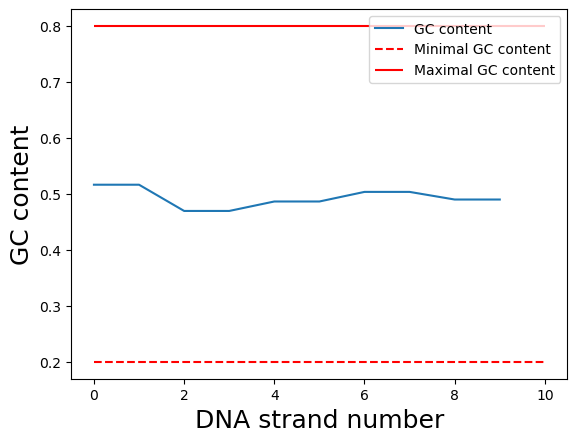

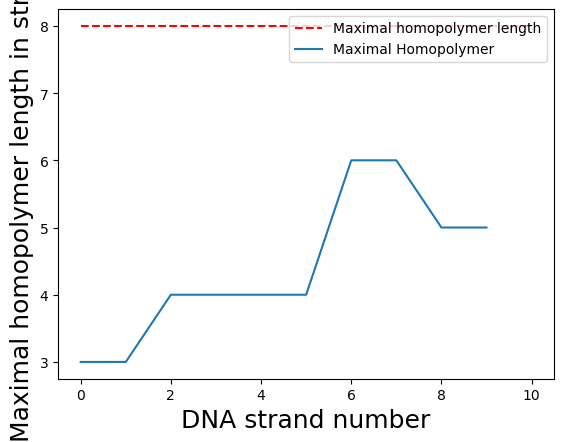

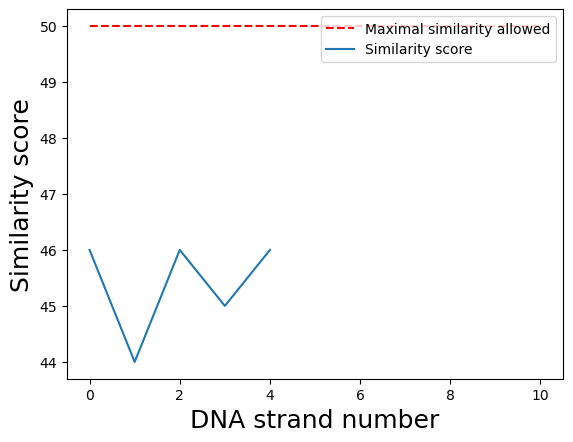

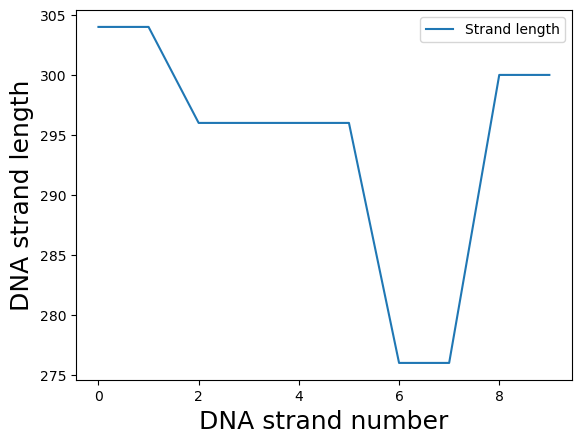

In [14]:
#@title { vertical-output: true}
# # What did we rely on in the last cell ? We relied on generating a random permutation !
# for i in range(2):
#   # Create a random number generator (rng) using seed i
#   rng = np.random.default_rng(i)
#   # And then choose a permutation or scramble:
#   scramble = "".join(rng.choice(['A' ,'C' ,'T' ,'G'], size = 10))
#   print(scramble)
#   print(rng.permutation([1,2,3,4,5,6,7,8,9,10]))

# #Then if we plug in again i == 1 then we can obtain the permutation again:
# i = 1
# rng = np.random.default_rng(i)
# scramble = "".join(rng.choice(['A' ,'C' ,'T' ,'G'], size = 10))
# # Omer@Ilaria - the following lines produce the same output:
# print(f"Testing for a scramble using i == {i}")
# print("Testing for a scramble using i =="+ str(i))
# print("Testing for a scramble using i ==",i)
# print(scramble)

# Now let's produce some graphics:
fig, ax = plt.subplots()
ax.plot(np.arange(0,len(dnaLibrary)), [checkGC(dnaLibrary[i]) for i in range(len(dnaLibrary))], label = 'GC content')
ax.set_xlabel('DNA strand number', size = 18)
ax.set_ylabel('GC content', size = 18)
ax.hlines(y=GC_LOW, xmin=0, xmax=len(dnaLibrary), linestyles = '--', color='r', label = 'Minimal GC content')
ax.hlines(y=GC_HIGH, xmin=0, xmax=len(dnaLibrary) ,color='r', label = 'Maximal GC content')
ax.legend()

figHomopolymer, axHomopolymer = plt.subplots()
axHomopolymer.hlines(y=MAX_HOMOPOLYMER, xmin=0, xmax=len(dnaLibrary), linestyles = '--', color='r', label = 'Maximal homopolymer length')
axHomopolymer.plot(np.arange(0,len(dnaLibrary)), [checkHomopolymer(dnaLibrary[i]) for i in range(len(dnaLibrary))], label = 'Maximal Homopolymer')
axHomopolymer.set_xlabel('DNA strand number', size = 18)
axHomopolymer.set_ylabel('Maximal homopolymer length in strand', size = 18)
axHomopolymer.legend()

figSimilarity, axSimilarity = plt.subplots()
axSimilarity.hlines(y=K, xmin=0, xmax=len(dnaLibrary), linestyles = '--', color='r', label = 'Maximal similarity allowed')
print(len(dnaLibrary))
scores = []
for i in range(len(dnaLibrary)//2):
  maxScore = 0
  for j in range(len(dnaLibrary)//2):
    if i != j:
      #print(aligner.score(dnaLibrary[2 * i], dnaLibrary[2 * j]))
      if maxScore < aligner.score(dnaLibrary[2 * i], dnaLibrary[2 * j]):
        maxScore = aligner.score(dnaLibrary[2 * i], dnaLibrary[2 * j])
  scores.append(maxScore)
print(scores)
axSimilarity.plot(np.arange(0,len(dnaLibrary)//2), scores, label = 'Similarity score')
axSimilarity.set_xlabel('DNA strand number', size = 18)
axSimilarity.set_ylabel('Similarity score', size = 18)
axSimilarity.legend()

figLength, axLength = plt.subplots()
axLength.plot(np.arange(0,len(dnaLibrary)), [len(dnaLibrary[i]) for i in range(len(dnaLibrary))], label = 'Strand length')
axLength.set_xlabel('DNA strand number', size = 18)
axLength.set_ylabel('DNA strand length', size = 18)
axLength.legend()

In [15]:

#@title { vertical-output: true}
# Testing badread using the following fast file:
 # To run badread we have to create a fasta file from the dna textual library.
sequences = {}
len(dnaLibrary)
MAXIMUM_DATA_DNA_LENGTH = 100
MINIMUM_DATA_DNA_LENGTH = 70
FRAGMENT_OVERLAP = 7 # up to 7 bases

for i in range(0, len(dnaLibrary), 2):
  # Check which fragment length is optimal:
  for fragmentLength in range(MINIMUM_DATA_DNA_LENGTH, MAXIMUM_DATA_DNA_LENGTH):
    if len(dnaLibrary[i]) % fragmentLength > MINIMUM_DATA_DNA_LENGTH:
      break
  numberOfFragments = np.int32(len(dnaLibrary[i]) // fragmentLength + ((len(dnaLibrary[i]) % fragmentLength)>0))
  print(f"{len(dnaLibrary[i]) // fragmentLength}   {(len(dnaLibrary[i]) % fragmentLength)}")
  print(f"Sequence length: {len(dnaLibrary[i])} yields {numberOfFragments} fragments of size {fragmentLength}")
  for j in range(numberOfFragments):
    if j != numberOfFragments - 1:
      fragment = str(dnaLibrary[i][j*fragmentLength : (j+1)*fragmentLength + FRAGMENT_OVERLAP])
    else:
      fragment = str(dnaLibrary[i][j*fragmentLength : ])
    sequences[f"Sequence{i} fragment{j} corresponding to text: {textLibrary[i//2]} encoded with seed {seeds[i//2]}. Maximum fragment size {fragmentLength + FRAGMENT_OVERLAP} which includes an overlap of {FRAGMENT_OVERLAP} bases."] = fragment


with open("sequencesFile.fasta", 'w') as output_file:
  for seq_id, seqence in sequences.items():
    identifier_line = ">" + seq_id + "\n"
    output_file.write(identifier_line)
    sequence_line = seqence + "\n"
    output_file.write(sequence_line)


3   73
Sequence length: 304 yields 4 fragments of size 77
3   71
Sequence length: 296 yields 4 fragments of size 75
3   71
Sequence length: 296 yields 4 fragments of size 75
2   90
Sequence length: 276 yields 3 fragments of size 93
3   72
Sequence length: 300 yields 4 fragments of size 76


In [16]:
!pip install --quiet git+https://github.com/rrwick/Badread.git

# Now use badread as instructed in https://github.com/rrwick/Badread
!badread simulate --reference sequencesFile.fasta --quantity 50x --error_model nanopore2020 --qscore_model nanopore2020 --identity 90,98,5 | gzip > reads.fastq.gz


  DEPRECATION: Building 'Badread' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'Badread'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  DEPRECATION: Building 'edlib' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'edlib'. Discussion can be found at https://github.com/pypa/pip/issues/6334
'gzip' is not recognized as an internal or external command,
operable program or batch f

In [17]:
#@title { vertical-output: true}
# Now we want to open the fastq.gz file and process the reads:
import gzip
from Bio.Seq import Seq as seq

def fastqIterator(fileName):
    with gzip.open(fileName,"rt") as f:
        count = 0
        while True:
            count += 1
            # Each FASTQ record consists of 4 lines
            identifier = f.readline()
            sequence = f.readline().strip()
            plus = f.readline().strip()
            quality = f.readline().strip()
            # Check for end of file
            if not identifier:
                break
            yield sequence
sequenceIterator = fastqIterator("reads.fastq.gz")
# Check for similarity between the dnaLibrary sequences and the sequences in the file:
from Bio import Align, pairwise2
# Declaring / instantiating an alignment function
aligner = Align.PairwiseAligner()
aligner.mode = 'local'
#AAAAAAAAAAAAGGGGGGGGGGGGGGGG
#            CCCCCCCCCCCCCCAAAAAAAAAAAAAAAAA
# See potential penalties to be defined here: https://biopython.org/docs/latest/Tutorial/chapter_pairwise.html#chapter-pairwise
aligner.match_score = 1 # Each match counts as 1
aligner.mismatch_score = -1
#aligner.gap_score = 0 # No penalty or gain for gaps
aligner.open_gap_score = -1
aligner.extend_gap_score = -1
matches = {}
for d in dnaLibrary:
  #d = dnaLibrary[i]
  matches[str(d)] =[]
  similarityThreshold = len(d) / 2
  for s in sequenceIterator:
      if (aligner.score(seq(s), seq(d))) > similarityThreshold:
        matches[str(d)].append(s)
#print(f"The original sequence is: {d}")
#print(f"Matches are:")
#for m in matches:
#  alignments = aligner.align(m,d)
#  for a in alignments:
#    print(a)
print(matches.keys())
#print(matches[matches.keys()[0]])

# There are two missing things:
# 1. Inverse function to the encode function.
# 2. Visualisation of the sequences in the fastq file


dict_keys(['CGATCGGCCTAGCGATCGTACGCCAGAACGATCTGAATTCAGAGATCCATAAAGAGAGAACGATCTGCATTCAGAGATCCATAAAGAGAGAACTAGATTCAGAGATCAATAAAGAGAGAACTATCTCACTAGCGTTCGGTCGCCATTCAGAGCGCTCTAGCGCCCGCCCGTGAGAGAGAACTATCTCACTAGCGTTCGGTCGCCAGTCCTCTCGGCCGCACTCACGGAATTCAGAGATCAAGAGAGAACGCGCGGCCGTACGTAATTCAGAGCTGCCGCCCGTACGTACGTTCTCTAGAGAGAA', 'TTCTCTCTAGAGAACGTACGTACGGGCGGCAGCTCTGAATTACGTACGGCCGCGCGTTCTCTCTTGATCTCTGAATTCCGTGAGTGCGGCCGAGAGGACTGGCGACCGAACGCTAGTGAGATAGTTCTCTCTCACGGGCGGGCGCTAGAGCGCTCTGAATGGCGACCGAACGCTAGTGAGATAGTTCTCTCTTTATTGATCTCTGAATCTAGTTCTCTCTTTATGGATCTCTGAATGCAGATCGTTCTCTCTTTATGGATCTCTGAATTCAGATCGTTCTGGCGTACGATCGCTAGGCCGATCG', 'AAATTTAATTATCACTGTAAGTGCGGTAACTTTCTCGATGCTCAGGTGCTCAAGCAGCCAGAGAAGTTATGTACAGCCCAGTCAGCGATTATACGCGGTTCTGCATGGGAGACAGAGATTCCTCAGGGCTGACTCACAATGGTTAAACCAGTCTTAGGCGTGCCAGCTAGATTGCAGCCACTTTGAATGCAATAGATTAGACTGAGAAATGGCAAAAGTAAATCTGTCGCCGGCATCCGTCGCAAGAAATAACCGGCGACGTAGTGCATACTACTGCCAACATCCCCTCAAGATTG', 'CAATCTTGAGGGGATGTTGGCAGTAGTATGCACTACGTCGCCGGTTATTTCTTGCGACGGATGCCGGCGACA

In [19]:
#@title { vertical-output: true}
# Now let's check that we can recover the data:
print(seeds)
print(len(dnaLibrary))
unscrambledLibrary = []
# First prepare a library of unscrambled DNA:
for i in range(0, len(dnaLibrary), 2):
  binaryCandidate = binaryLibrary[i//2]
  nextCandidateDNA = byteToBases(binaryCandidate, len(binaryCandidate))
  print(f"Sequence {i}")
  print(dnaLibrary[i])
  print(f"Seed used: {seeds[i//2]} ")
  if seeds[i//2] == 0:
    unscrambledDNA = dnaLibrary[i]
    print(f"***{str(unscrambledDNA)}")
    print(f"***{nextCandidateDNA}")
    print(f"{(str(unscrambledDNA) == nextCandidateDNA)}")
  else:
    rng = np.random.default_rng(seeds[i//2])
    scramble = "".join(rng.choice(['A' ,'C' ,'T' ,'G'], size = len(dnaLibrary[i])))
    print(f"Checking that the scrambling value can be reproduced...")
    assert(scramble == scrambles[i//2])
    print(f"Success !")
    print(f"Forward checking...")
    assert(addScrambleToDnaSequence(nextCandidateDNA, scramble) == nextCandidateDNA)
    print(f"Success !")
    print(f"Backwards checking...")
    unscrambledDNA = addScrambleToDnaSequence(dnaLibrary[i], scramble)
  print(f"Checking if the DNA in the library could be unscrambled...")
  assert (unscrambledDNA == dnaLibrary[i])
  print(f"Success !")
  unscrambledLibrary.append(unscrambledDNA)



for i in range(len(textLibrary)):
  print(f"Orginal text is: {textLibrary[i]}")
  sourceSequence = byteToBases(binaryLibrary[i], len(binaryCandidate))
  print(f"Simple translation to DNA: {sourceSequence}")
  print(f"Is there a match between the source sequence and the unscrambled DNA: {unscrambledDNA[i] == sourceSequence}")





[0, 1, 2, 1, 1]
10
Sequence 0
CGATCGGCCTAGCGATCGTACGCCAGAACGATCTGAATTCAGAGATCCATAAAGAGAGAACGATCTGCATTCAGAGATCCATAAAGAGAGAACTAGATTCAGAGATCAATAAAGAGAGAACTATCTCACTAGCGTTCGGTCGCCATTCAGAGCGCTCTAGCGCCCGCCCGTGAGAGAGAACTATCTCACTAGCGTTCGGTCGCCAGTCCTCTCGGCCGCACTCACGGAATTCAGAGATCAAGAGAGAACGCGCGGCCGTACGTAATTCAGAGCTGCCGCCCGTACGTACGTTCTCTAGAGAGAA
Seed used: 0 
***CGATCGGCCTAGCGATCGTACGCCAGAACGATCTGAATTCAGAGATCCATAAAGAGAGAACGATCTGCATTCAGAGATCCATAAAGAGAGAACTAGATTCAGAGATCAATAAAGAGAGAACTATCTCACTAGCGTTCGGTCGCCATTCAGAGCGCTCTAGCGCCCGCCCGTGAGAGAGAACTATCTCACTAGCGTTCGGTCGCCAGTCCTCTCGGCCGCACTCACGGAATTCAGAGATCAAGAGAGAACGCGCGGCCGTACGTAATTCAGAGCTGCCGCCCGTACGTACGTTCTCTAGAGAGAA
***CGATCGGCCTAGCGATCGTACGCCAGAACGATCTGAATTCAGAGATCCATAAAGAGAGAACGATCTGCATTCAGAGATCCATAAAGAGAGAACTAGATTCAGAGATCAATAAAGAGAGAACTATCTCACTAGCGTTCGGTCGCCATTCAGAGCGCTCTAGCGCCCGCCCGTGAGAGAGAACTATCTCACTAGCGTTCGGTCGCCAGTCCTCTCGGCCGCACTCACGGAATTCAGAGATCAAGAGAGAACGCGCGGCCGTACGTAATTCAGAGCTGCCGCCCGTACGTACGTTCTCTAGAGAGAA
True
Checking if the DNA in the lib

AssertionError: 

Total output chunks: 726
First 5 chunks:
{'png_chunk_type': 'IHDR', 'field': 'header', 'subchunk_index': 0, 'bits': '0000000000000000000000000000110101001001010010000100010001010010', 'dna': 'AAAAAAAAAAAAAATCCAGCCAGACACACCAG'}
{'png_chunk_type': 'IHDR', 'field': 'data', 'subchunk_index': 0, 'bits': '0000000000000000000001001000010000000000000000000000000001111111', 'dna': 'AAAAAAAAAACAGACAAAAAAAAAAAAACTTT'}
{'png_chunk_type': 'IHDR', 'field': 'data', 'subchunk_index': 1, 'bits': '0000100000000011000000000000000000000000', 'dna': 'AAGAAAATAAAAAAAAAAAA'}
{'png_chunk_type': 'IHDR', 'field': 'checksum', 'subchunk_index': 0, 'bits': '10101001000101101110100111001101', 'dna': 'GGGCACCGTGGCTATC'}
{'png_chunk_type': 'PLTE', 'field': 'header', 'subchunk_index': 0, 'bits': '0000000000000000000000110000000001010000010011000101010001000101', 'dna': 'AAAAAAAAAAATAAAACCAACATACCCACACC'}


Reconstructed PNG written to: C:\Users\Omer\strandDisplacementPNG\reconstructed.png


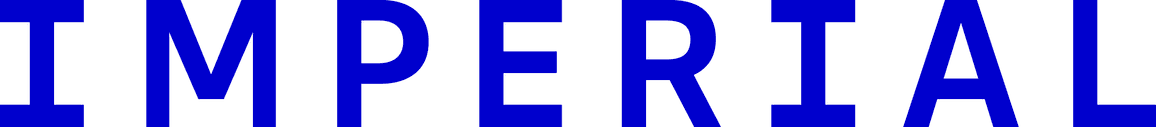